<a href="https://colab.research.google.com/github/kilarson/msa/blob/main/msa_structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#phangs_structure
# python 3
#


#-------------------#
# Required Inputs #
#-------------------#
#command line inputs
# galaxy name
# tracer_band:  v or nuv
# smooth_step:  2 or 3
#------------#
#Required Files:
# Distance file
# reginfo (pipe1)
# dolphot photometry (pipe2)
#For Figures:
#BC03 ssp model line:   infile_SSP='models-block-bc03-0cov.txt'
# To cross-check with clusters
# Candidate_allclusters - output from Sinan's pipeline


import numpy as np
from scipy import stats
import pylab as py

import os
import time
from os import path
import sys
import time

import pandas as pd
#from tqdm import tqdm

#--
from datetime import datetime
from importlib import import_module
import shutil

from collections import OrderedDict
import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from astropy.io import fits
from astropy.io import ascii
from astropy.wcs import WCS
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord

#import wshierarchy
#import wsstructure

from time import sleep
from tqdm import tqdm
#import pcigale
#from pcigale.analysis_modules.pdf_analysis import PdfAnalysis

In [4]:
# Using Google Colab mode?
google_colab = True


if google_colab:
    from google.colab import drive

    # Mount Google Drive
    drive.mount('/content/drive')

    colab_notebooks_path = '/content/drive/My Drive/Colab Notebooks/'
    if colab_notebooks_path not in sys.path:
        sys.path.insert(0, colab_notebooks_path)

    # Now you can access files in your Google Drive, for example:
    # import pandas as pd
    google_dir = '/content/drive/My Drive/PHANGS/NGC4826/'
    #colab_dir = 'content/drive/My Drive/Colab Notebooks/'
    #

import wshierarchy
import wsstructure

Mounted at /content/drive


In [5]:
# -----------------------------------------------------
# ------------------------------
#          inputs
# ------------------------------
# ------------------------------
# Input galaxy name, tracer_band, and Smooth_scale as command line input
# ------------------------------
#gal = sys.argv[1]
gal = 'ngc4826' # ngc1566'
print('Galaxy: ', gal)
tracer_band = 'nuv'
if google_colab:
  base_dir = '/content/drive/My Drive/PHANGS/'
  IR4_dir = '/content/drive/Shared drives/PHANGS/Archive/Products/cluster_catalogs/IR4/'
  objdir = IR4_dir+'multiscale_stellar_associations/'+gal+'/'+tracer_band+'select/'
  dolphot_dir = base_dir + 'dolphot/'
  outdir=base_dir + gal+'/colab_outfiles/'
else:
  base_dir = '/Users/kilarson/Library/CloudStorage/Box-Box/'
  Larson_clouddir = base_dir='My Documents - Kirsten Larson/Kirsten_PHANGS/'
  PHANGS_clouddir = base_dir='PHANGS-HST Anaylsis Working Group/'
  #datadir = Larson_clouddir+'Data/'
  catdir = Larson_clouddir+'Data/catalogs/'
  objdir = catdir+'IR4/multiscale_stellar_associations/'+gal+'/'+tracer_band+'select/'
  outdir = Larson_clouddir+'Hierarchical_analysis/'+gal+'_outfiles_'+tracer_band+'band/'
  dolphot_dir = catdir+'dolphot/'
#

#tracer_band = sys.argv[2]
#print('tracer star band: ', tracer_band)
#datadir = '/Users/klarson/Dropbox/Phangs/Data/' # change this to match your chosen data directory
#datadir = PHANGS_clouddir+'CLUSTER CATALOG REALEASES/Internal Catalog Releases/IR4/Association Related/'
#objdir = datadir+gal+'/'+tracer_band+'select/'



#datadir = sys.argv[4]
#print('Data dir: ', datadir)
print('Obj dir:', objdir)
# ----
dolphot_combfile = gal+'_uvis_dolphot.fits'  #default dolphot cataloge name
#dolphot_combfile = gal+'_uvis_dolphot_v0.9.fits'
#outdir = 'IR4/'
print('Output dir:', outdir)


'''
if (len(sys.argv) == 6):
    Absmag_limit = sys.argv[5]
    Absmag_limit_str = str(Absmag_limit)
    print('Absolute magnitude limit: '+ str(Absmag_limit))
    outdir = gal+'_outfiles_'+tracer_band+'band_smo'+str(smooth_step)+'_AbsMag'+Absmag_limit_str[0:2]+'/'
    Absmag_limit = np.double(Absmag_limit)
'''

#outdir = gal+'_outfiles_oct30_newsmooth/'
#outdir2 = outdir+'photometry/' #output for pipe2 files
#statfile = open(gal+'_stats.txt','w')
# -----------------------------------------------------
program_start_time = time.time()



Galaxy:  ngc4826
Obj dir: /content/drive/Shared drives/PHANGS/Archive/Products/cluster_catalogs/IR4/multiscale_stellar_associations/ngc4826/nuvselect/
Output dir: /content/drive/My Drive/PHANGS/ngc4826/colab_outfiles/


In [8]:
# ------------------------------
#   check for output directory
# ------------------------------
if (path.exists(outdir)==True):
    print('Output directory: '+outdir +' already exists')
if (path.exists(outdir)==False):
    os.mkdir(outdir)
    print("Output Directory '% s' created" % outdir)

# ---------------------------------
# Read in PHANGS dolphot table  #
# ---------------------------------

#doltbl = fits.getdata(PHANGS_clouddir+'Dolphot/Catalogs/'+gal+'/'+dolphot_combfile,1)
doltbl = fits.getdata(dolphot_dir+dolphot_combfile,1)

##  dolphot_combfile = gal+'_uvis_dolphot.fits'

xstar_dol = doltbl.Dolphot_x - 0.5
ystar_dol = doltbl.Dolphot_y - 0.5


Output directory: /content/drive/My Drive/PHANGS/ngc4826/colab_outfiles/ already exists


In [25]:
doltbl.columns

ColDefs(
    name = 'Dolphot_ID'; format = 'K'
    name = 'Dolphot_Target'; format = '12A'
    name = 'Dolphot_x'; format = 'D'
    name = 'Dolphot_y'; format = 'D'
    name = 'Chi'; format = 'D'
    name = 'S2N'; format = 'D'
    name = 'Sharp'; format = 'D'
    name = 'Round'; format = 'D'
    name = 'PosAngle'; format = 'K'
    name = 'Crowd'; format = 'D'
    name = 'ObjectType'; format = 'K'
    name = 'TotCnt_WFC3_F275W'; format = 'D'
    name = 'TotSkyLev_WFC3_F275W'; format = 'D'
    name = 'NormCntRate_WFC3_F275W'; format = 'D'
    name = 'NormCntRateUnc_WFC3_F275W'; format = 'D'
    name = 'Mag_WFC3_F275W'; format = 'D'
    name = 'MagUnc_WFC3_F275W'; format = 'D'
    name = 'Chi_WFC3_F275W'; format = 'D'
    name = 'S2N_WFC3_F275W'; format = 'D'
    name = 'Sharp_WFC3_F275W'; format = 'D'
    name = 'Round_WFC3_F275W'; format = 'D'
    name = 'Crowd_WFC3_F275W'; format = 'D'
    name = 'PhotQualFlag_WFC3_F275W'; format = 'K'
    name = 'TotCnt_WFC3_F336W'; format = 'D'
    n

In [9]:
# Find Tracer stars
if (tracer_band == 'nuv'):
    input_stars = np.where( (doltbl.S2N_WFC3_F275W >7) & (doltbl.Sharp_WFC3_F275W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F275W < 4) & (doltbl.S2N_WFC3_F336W >3) )  #no mag limit

if (tracer_band == 'v'):
    input_stars = np.where( (doltbl.S2N_WFC3_F555W >7) & (doltbl.Sharp_WFC3_F555W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F555W < 4) & (doltbl.S2N_WFC3_F438W >3) )  #no mag limit

'''
if (len(sys.argv) == 6):
    print('AbsMag Limit')
    Absmag_limit = np.double(Absmag_limit)
    if (tracer_band == 'nuv'):
        input_stars = np.where( (doltbl.S2N_WFC3_F275W >7) & (doltbl.Sharp_WFC3_F275W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F275W < 4) & (doltbl.S2N_WFC3_F336W >3) & (doltbl.Mag_WFC3_F275W-dist_mod <= Absmag_limit) )
    if (tracer_band == 'v'):
        input_stars = np.where( (doltbl.S2N_WFC3_F555W >7) & (doltbl.Sharp_WFC3_F555W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F555W < 4) & (doltbl.S2N_WFC3_F438W >3) & (doltbl.Mag_WFC3_F555W-dist_mod <= Absmag_limit ) )

'''



"\nif (len(sys.argv) == 6):\n    print('AbsMag Limit')\n    Absmag_limit = np.double(Absmag_limit)\n    if (tracer_band == 'nuv'):\n        input_stars = np.where( (doltbl.S2N_WFC3_F275W >7) & (doltbl.Sharp_WFC3_F275W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F275W < 4) & (doltbl.S2N_WFC3_F336W >3) & (doltbl.Mag_WFC3_F275W-dist_mod <= Absmag_limit) )\n    if (tracer_band == 'v'):\n        input_stars = np.where( (doltbl.S2N_WFC3_F555W >7) & (doltbl.Sharp_WFC3_F555W**2. <= 0.15) & (doltbl.PhotQualFlag_WFC3_F555W < 4) & (doltbl.S2N_WFC3_F438W >3) & (doltbl.Mag_WFC3_F555W-dist_mod <= Absmag_limit ) )\n\n"

In [18]:
#Skip?
#imgfile = datadir+gal+'/'+gal+'_uvis_f555w_exp_drc_sci.fits'

#use ws16 ID mask for image reference
imgfile=objdir+'ws16pc/'+'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-ws16pc-idmask.fits.gz'

refimg = fits.getdata(imgfile)
refhdr = fits.getheader(imgfile)
refw = WCS(imgfile) #WCS info
wcs_header = refw.to_header() #WSC header for img

In [ ]:
#skip?
#'''
# ------------------------------
#    Read in galaxy distance
# ------------------------------
#Adopted distance NGC 1566: 18 Mpc
#Adopted distance NGC 3351: 10 Mpc
#Adopted distance NGC 1433: 8.3 Mpc

distfile = 'distance_table.txt'
gal_distances= pd.read_csv(datadir+distfile,header=0)

dist_idx = np.where(gal_distances['rootName']==gal)
dist_idx=dist_idx[0]
distmpc = gal_distances.current[dist_idx[0]]
print(gal+ ' -Using Current distance: '+ str(distmpc)+'Mpc')
dist_mod =  5.0* np.log10(distmpc*1e6) -5.0
# ---------------------------------

#'''

ngc4826 -Using Current distance: 4.41Mpc


In [10]:
#'''
#pixscale = 0.03962 # arcsec / pixel
#as2pc= (4.848*distmpc)
#pcpix =   pixscale * as2pc #parsec/pixel
#min_scale_pc = 8
#pc_scales = np.array([min_scale_pc,min_scale_pc *2.,min_scale_pc* 2**2.,min_scale_pc* 2**3.,min_scale_pc* 2**4.,min_scale_pc* 2**5.,min_scale_pc* 2**6.])
#print(pc_scales)
#'''

pixscale = 0.03962 # arcsec / pixel



In [11]:
#Find WS directories
tmp_listdir = os.listdir(objdir)

level_listdir = [f for f in tmp_listdir if 'pc' in f]
print(level_listdir)
#WARNING - 'level_listdir' might not be in accending size order.#
if (len(level_listdir) == 3):
    pc_scales = ['16','32','64']
    level_listdir = ['ws16pc', 'ws32pc', 'ws64pc']
    nlevel=3

if (len(level_listdir) == 4):
    pc_scales = ['8','16','32','64']
    level_listdir = ['ws8pc','ws16pc', 'ws32pc', 'ws64pc']
    nlevel=4

print(pc_scales)


['ws16pc', 'ws32pc', 'ws64pc', 'ws8pc']
['8', '16', '32', '64']


In [ ]:
    #Skip
    '''
    i=0
    photfile0 = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_Dolphot'

    reginfo_file0 = outdir+gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_reginfo.fits'
    reginfo_tbl0 = fits.getdata(reginfo_file,1)
    #ws_file = 'clustsub_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_'+pmax_name+'_ws.fits'
    ws_file = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_idmask.fits'
    ws_idmap0 = fits.getdata(outdir+ws_file)
    num_markers0= np.max(ws_idmap0)#-1
    '''

"\ni=0\nphotfile0 = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_Dolphot'\n\nreginfo_file0 = outdir+gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_reginfo.fits'\nreginfo_tbl0 = fits.getdata(reginfo_file,1)\n#ws_file = 'clustsub_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_'+pmax_name+'_ws.fits'\nws_file = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_idmask.fits'\nws_idmap0 = fits.getdata(outdir+ws_file)\nnum_markers0= np.max(ws_idmap0)#-1\n"

In [19]:
i=0
reginfo_file0 =level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-main.fits'
reginfo_tbl0 = fits.getdata(objdir+reginfo_file0,1)
ws_file0 = level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-idmask.fits.gz'
ws_idmap0 = fits.getdata(objdir+ws_file0)
num_markers0= np.max(ws_idmap0)#-1

print(reginfo_tbl0.columns)

ColDefs(
    name = 'reg_id'; format = 'D'
    name = 'reg_x'; format = 'D'
    name = 'reg_y'; format = 'D'
    name = 'reg_ra'; format = 'D'
    name = 'reg_dec'; format = 'D'
    name = 'reg_area'; format = 'D'
    name = 'reg_rad'; format = 'D'
    name = 'NUV_dolflux_mjy'; format = 'D'
    name = 'NUV_dolflux_mjy_err'; format = 'D'
    name = 'U_dolflux_mjy'; format = 'D'
    name = 'U_dolflux_mjy_err'; format = 'D'
    name = 'B_dolflux_mjy'; format = 'D'
    name = 'B_dolflux_mjy_err'; format = 'D'
    name = 'V_dolflux_mjy'; format = 'D'
    name = 'V_dolflux_mjy_err'; format = 'D'
    name = 'I_dolflux_mjy'; format = 'D'
    name = 'I_dolflux_mjy_err'; format = 'D'
    name = 'NUV_dolmag_vega'; format = 'D'
    name = 'NUV_dolmag_vega_err'; format = 'D'
    name = 'U_dolmag_vega'; format = 'D'
    name = 'U_dolmag_vega_err'; format = 'D'
    name = 'B_dolmag_vega'; format = 'D'
    name = 'B_dolmag_vega_err'; format = 'D'
    name = 'V_dolmag_vega'; format = 'D'
    name = 'V_

In [22]:
i=1
reginfo_file1 =level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-main.fits'
reginfo_tbl1 = fits.getdata(objdir+reginfo_file1,1)
ws_file1 = level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-idmask.fits.gz'
ws_idmap1 = fits.getdata(objdir+ws_file1)
num_markers1= np.max(ws_idmap1)#-1

i=2
reginfo_file2 =level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-main.fits'
reginfo_tbl2 = fits.getdata(objdir+reginfo_file2,1)
ws_file2 = level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-idmask.fits.gz'
ws_idmap2 = fits.getdata(objdir+ws_file2)
num_markers2= np.max(ws_idmap2)#-1

if nlevel == 4:
    i=3
    reginfo_file3 =level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-main.fits'
    reginfo_tbl3 = fits.getdata(objdir+reginfo_file3,1)
    ws_file3 = level_listdir[i]+'/'+ 'PHANGS_IR4_hst_wfc3_'+gal+'_v1p3_multi_assoc-'+tracer_band+'select-'+level_listdir[i]+'-idmask.fits.gz'
    ws_idmap3 = fits.getdata(objdir+ws_file3)
    num_markers3= np.max(ws_idmap3)#-1


In [ ]:
#test
#dolstar_ids = wsstructure.starchild(ws_idmap0,doltbl.Dolphot_x-.5,doltbl.Dolphot_y-.5)

In [ ]:
#test
#tracerstar_ids = starchild(ws_idmask,doltbl.Dolphot_x[input_stars]+ 0.5,doltbl.Dolphot_y[input_stars]+ 0.5)
#tracerstar_ids = wsstructure.starchild(ws_idmap0,doltbl.Dolphot_x[input_stars],doltbl.Dolphot_y[input_stars])

In [ ]:
    #Skip
    '''
    i=1
    photfile1 = gal+'_'+tracer_band+'_ws'+pc_scales[i])+'pc_hpfilt'+str(smooth_step)+'_Dolphot'

    reginfo_file1 = outdir+gal+'_'+tracer_band+'_ws'+pc_scales[i]+'pc_hpfilt'+str(smooth_step)+'_reginfo.fits'
    reginfo_tbl1 = fits.getdata(reginfo_file1,1)
    #ws_file = 'clustsub_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_'+pmax_name+'_ws.fits'
    ws_file = gal+'_'+tracer_band+'_ws'+pc_scales[i]+'pc_hpfilt'+str(smooth_step)+'_idmask.fits'
    ws_idmap1 = fits.getdata(outdir+ws_file)
    num_markers1= np.max(ws_idmap1)#-1
    '''

In [ ]:
'''
    i=2
    photfile2 = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_Dolphot'

    reginfo_file2 = outdir+gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_reginfo.fits'
    reginfo_tbl2 = fits.getdata(reginfo_file2,1)
    #ws_file = 'clustsub_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_'+pmax_name+'_ws.fits'
    ws_file2 = gal+'_'+tracer_band+'_ws'+str(pc_scales[i].astype(np.int))+'pc_hpfilt'+str(smooth_step)+'_idmask.fits'
    ws_idmap2 = fits.getdata(outdir+ws_file2)
    num_markers2= np.max(ws_idmap2)#-1

In [ ]:
'''
dolstar_ids1 = wsstructure.starchild(ws_idmap,doltbl.Dolphot_x-.5,doltbl.Dolphot_y-.5)
tracerstar_ids1 = wsstructure.starchild(ws_idmap,doltbl.Dolphot_x[input_stars]-.5,doltbl.Dolphot_y[input_stars]-.5)

In [ ]:
'''
def starchild(ws_idmap,xstar,ystar):
    n_reg = np.max(ws_idmap)
    ws_id = range(1,n_reg+1)
    star_ids =  [[] for i in range(n_reg)] #empty list of lists

    for n in range(len(xstar)):
        region = ws_idmap[(np.round(ystar[n])).astype(np.int),(np.round(xstar[n])).astype(np.int)]
        #print(region,n)
        #find ws_region
        if (region != 0):
            star_ids[region-1].append(n)

    return(star_ids)
'''

In [ ]:
'''
ws0_dolphot_ids = starchild(ws_idmap0,doltbl.Dolphot_x,doltbl.Dolphot_y)


In [23]:
#test
print(len(reginfo_tbl0),len(reginfo_tbl1), len(reginfo_tbl2), len(reginfo_tbl3))
print(num_markers0,num_markers1,num_markers2,num_markers3)

577 454 252 91
577 454 252 91


In [27]:
ws0_dolphot_ids = wsstructure.starchild(ws_idmap0,doltbl.Dolphot_x-0.5,doltbl.Dolphot_y-0.5,doltbl.Dolphot_ID)
ws1_dolphot_ids = wsstructure.starchild(ws_idmap1,doltbl.Dolphot_x-0.5,doltbl.Dolphot_y-0.5,doltbl.Dolphot_ID)
ws2_dolphot_ids = wsstructure.starchild(ws_idmap2,doltbl.Dolphot_x-0.5,doltbl.Dolphot_y-0.5,doltbl.Dolphot_ID)
if nlevel == 4:
    ws3_dolphot_ids = wsstructure.starchild(ws_idmap3,doltbl.Dolphot_x-0.5,doltbl.Dolphot_y-0.5,doltbl.Dolphot_ID)



In [28]:
ws0_tracerstar_ids = wsstructure.starchild(ws_idmap0,doltbl.Dolphot_x[input_stars]-0.5,doltbl.Dolphot_y[input_stars]-0.5,doltbl.Dolphot_ID[input_stars])
ws1_tracerstar_ids = wsstructure.starchild(ws_idmap1,doltbl.Dolphot_x[input_stars]-0.5,doltbl.Dolphot_y[input_stars]-0.5,doltbl.Dolphot_ID[input_stars])
ws2_tracerstar_ids = wsstructure.starchild(ws_idmap2,doltbl.Dolphot_x[input_stars]-0.5,doltbl.Dolphot_y[input_stars]-0.5,doltbl.Dolphot_ID[input_stars])
if nlevel == 4:
    ws3_tracerstar_ids = wsstructure.starchild(ws_idmap3,doltbl.Dolphot_x[input_stars]-0.5,doltbl.Dolphot_y[input_stars]-0.5,doltbl.Dolphot_ID[input_stars])


In [29]:
#test
print(np.max(ws_idmap0),num_markers0)
print(np.max(ws_idmap1),num_markers1)
print(np.max(ws_idmap2),num_markers2)

577 577
454 454
252 252


In [34]:
# read in new cluster catalog
cluster_dir = dolphot_dir
class12_file = cluster_dir+'hlsp_phangs-cat_hst_multi_dr5-human-class1+2_PRIMARY.fits'
class12_tbl = fits.getdata(class12_file,1)
class12_tbl.columns

ColDefs(
    name = 'INDEX'; format = 'K'
    name = 'PHANGS_GALAXY'; format = '7A'
    name = 'PHANGS_DMPC'; format = 'D'; unit = 'Mpc'
    name = 'PHANGS_DERR'; format = 'D'; unit = 'Mpc'
    name = 'PHANGS_DM'; format = 'D'; unit = 'mag'
    name = 'ID_PHANGS_CLUSTER'; format = 'K'
    name = 'ID_PHANGS_CANDIDATE'; format = 'K'
    name = 'PHANGS_X'; format = 'D'; unit = 'pix'
    name = 'PHANGS_Y'; format = 'D'; unit = 'pix'
    name = 'PHANGS_RA'; format = 'D'; unit = 'deg'
    name = 'PHANGS_DEC'; format = 'D'; unit = 'deg'
    name = 'PHANGS_CLUSTER_CLASS_HUMAN'; format = 'K'
    name = 'PHANGS_CLUSTER_CLASS_ML_VGG'; format = 'K'
    name = 'PHANGS_CLUSTER_CLASS_ML_VGG_QUAL'; format = 'D'
    name = 'PHANGS_NUV_VEGA'; format = 'D'; unit = 'mag'
    name = 'PHANGS_NUV_VEGA_ERR'; format = 'D'; unit = 'mag'
    name = 'PHANGS_U_VEGA'; format = 'D'; unit = 'mag'
    name = 'PHANGS_U_VEGA_ERR'; format = 'D'; unit = 'mag'
    name = 'PHANGS_B_VEGA'; format = 'D'
    name = 'PHANGS_B_V

In [40]:
class12_clusters_tbl = class12_tbl[class12_tbl['PHANGS_GALAXY'] == gal]
#class12_clusters_tbl

ws0_cluster12_ids = wsstructure.starchild(ws_idmap0,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.ID_PHANGS_CLUSTER)
ws1_cluster12_ids = wsstructure.starchild(ws_idmap1,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.ID_PHANGS_CLUSTER)
ws2_cluster12_ids = wsstructure.starchild(ws_idmap2,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.ID_PHANGS_CLUSTER)
if nlevel == 4:
    ws3_cluster12_ids = wsstructure.starchild(ws_idmap3,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.PHANGS_X,class12_clusters_tbl.ID_PHANGS_CLUSTER)


In [47]:
class12_clusters_tbl.size

173

In [51]:
ws3_cluster12_ids

[[],
 [],
 [],
 [],
 [np.int64(44), np.int64(503)],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [np.int64(107), np.int64(660), np.int64(746)],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [np.int64(1),
  np.int64(3),
  np.int64(9),
  np.int64(64),
  np.int64(75),
  np.int64(86),
  np.int64(87),
  np.int64(133),
  np.int64(158),
  np.int64(243),
  np.int64(300),
  np.int64(440),
  np.int64(514),
  np.int64(679),
  np.int64(681),
  np.int64(694),
  np.int64(701),
  np.int64(739),
  np.int64(751)],
 [],
 [],
 [],
 [],
 [np.int64(93), np.int64(610), np.int64(733)],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [np.int64(467), np.int64(470), np.int64(480), np.int64(689)],
 [np.int64(308)],
 [],
 [np.int64(162), np.int64(217), np.int64(652)],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [np.int64(599)],
 [],
 [],
 [np.int64(375)],

In [ ]:
from tqdm import trange

def regchild(ws_idmap_p,ws_idmap_c):
    #ws_idmap_p = parent
    #ws_idmap_c = child

    n_regp = np.max(ws_idmap_p)
    ws_idp = range(1,n_regp+1)
    n_regc = np.max(ws_idmap_c)
    ws_idc = range(1,n_regc+1)

    child_ids = [[] for i in range(n_regp)] #empty list of lists
    child_noverlap = [[] for i in range(n_regp)] #empty list of lists
    child_npix = [[] for i in range(n_regp)] #empty list of lists
    nchild = [[] for i in range(n_regp)] #empty list of lists

    parent_id = [[] for i in range(n_regc)]
    parent_noverlap = [[] for i in range(n_regc)] #empty list of lists
    parent_npix = [[] for i in range(n_regc)] #empty list of lists

    #n_reg1
    for n in trange(n_regp):
        parent_region = np.where(ws_idmap_p == ws_idp[n])
        #find children
        child_ids_tmp,child_noverlap_tmp =np.unique(ws_idmap_c[parent_region],return_counts=True)
        #remove unique elements=zero (first element of array)
        #print(child_ids_tmp[0])
        if (child_ids_tmp[0]== 0):
            child_ids_tmp = child_ids_tmp[1:]
            child_noverlap_tmp = child_noverlap_tmp[1:]
        child_ids[n] =child_ids_tmp
        child_noverlap[n] =child_noverlap_tmp
        #print(child_ids[n])
        nchild[n] = len(child_ids[n])

        if (nchild[n] > 0):
            for i in range(nchild[n]):
                child_region = np.where(ws_idmap_c == child_ids[n][i])
                child_size = len(child_region[0])
                child_npix[n].append(len(child_region[0]))

        #star_ids[region-1].append(n)

    return(child_ids, child_noverlap, child_npix,nchild)


In [30]:
ws1_child_ids, ws1_child_noverlap, ws1_child_npix,ws1_nchild= wsstructure.regchild(ws_idmap1,ws_idmap0) #(parent, child) = child


100%|██████████| 454/454 [05:41<00:00,  1.33it/s]


In [48]:
ws0_parent_ids, ws0_parent_noverlap, ws0_parent_npix,ws0_nparent = wsstructure.regchild(ws_idmap0,ws_idmap1) #(child, parent) =parent output


100%|██████████| 577/577 [06:11<00:00,  1.55it/s]


In [49]:
ws2_child_ids, ws2_child_noverlap, ws2_child_npix, ws2_nchild = wsstructure.regchild(ws_idmap2,ws_idmap1) #(parent, child) = child
ws1_parent_ids, ws1_parent_noverlap, ws1_parent_npix,ws1_nparent = wsstructure.regchild(ws_idmap1,ws_idmap2) #(child, parent) =parent output


100%|██████████| 454/454 [04:47<00:00,  1.58it/s]


In [50]:
#if 4 levels
if nlevel==4:
    ws3_child_ids, ws3_child_noverlap, ws3_child_npix, ws3_nchild = wsstructure.regchild(ws_idmap3,ws_idmap2) #(parent, child) = child
    ws2_parent_ids, ws2_parent_noverlap, ws2_parent_npix,ws2_nparent = wsstructure.regchild(ws_idmap2,ws_idmap3) #(child, parent) =parent output


100%|██████████| 252/252 [02:31<00:00,  1.67it/s]


In [ ]:
reginfo_tbl0.columns

ColDefs(
    name = 'reg_id'; format = 'D'
    name = 'reg_x'; format = 'D'
    name = 'reg_y'; format = 'D'
    name = 'reg_ra'; format = 'D'
    name = 'reg_dec'; format = 'D'
    name = 'reg_area'; format = 'D'
    name = 'reg_rad'; format = 'D'
    name = 'NUV_dolflux_mjy'; format = 'D'
    name = 'NUV_dolflux_mjy_err'; format = 'D'
    name = 'U_dolflux_mjy'; format = 'D'
    name = 'U_dolflux_mjy_err'; format = 'D'
    name = 'B_dolflux_mjy'; format = 'D'
    name = 'B_dolflux_mjy_err'; format = 'D'
    name = 'V_dolflux_mjy'; format = 'D'
    name = 'V_dolflux_mjy_err'; format = 'D'
    name = 'I_dolflux_mjy'; format = 'D'
    name = 'I_dolflux_mjy_err'; format = 'D'
    name = 'NUV_dolmag_vega'; format = 'D'
    name = 'NUV_dolmag_vega_err'; format = 'D'
    name = 'U_dolmag_vega'; format = 'D'
    name = 'U_dolmag_vega_err'; format = 'D'
    name = 'B_dolmag_vega'; format = 'D'
    name = 'B_dolmag_vega_err'; format = 'D'
    name = 'V_dolmag_vega'; format = 'D'
    name = 'V_

In [ ]:
print(n_reg1, np.max(ws_idmap1))

91 91


In [ ]:
## Create dataframes for each scale level
#lvl0 = Level 0. For clusters that have no parent association at any level: orphan clusters.
#lvl1 = first scale level of the accociations
#empty ws0 dataframe
#lvl0['pc_scale'] = pc_scales[0] #scale level in parsecs

lvl0 = pd.DataFrame()

n_reg0 = np.max(ws_idmap0)
ws_id0 = range(1,n_reg0+1)
lvl0['id'] = ws_id0
lvl0['parent_ids'] = ws0_parent_ids
lvl0['nparent'] = ws0_nparent
lvl0['dolphot_ids']=ws0_dolphot_ids
lvl0['tracer_ids']= ws0_tracerstar_ids
lvl0['peak_xpos'] = reginfo_tbl0.reg_x
lvl0['peak_ypos'] = reginfo_tbl0.reg_y
lvl0['peak_ra'] = reginfo_tbl0.reg_ra
lvl0['peak_dec'] = reginfo_tbl0.reg_dec
lvl0['area_pc'] = reginfo_tbl0.reg_area #pc?
lvl0['rad_pc'] = reginfo_tbl0.reg_rad #pc?
#lvl0['ntracer'] = reginfo_tbl0.ntracer_reg
lvl0['V_dolflux_mjy'] = reginfo_tbl0.V_dolflux_mjy
lvl0['NUV_dolflux_mjy'] = reginfo_tbl0.NUV_dolflux_mjy

#
lvl0['cluster12_ids']= ws0_cluster12_ids

lvl1 = pd.DataFrame()
n_reg1 = np.max(ws_idmap1)
ws_id1 = range(1,n_reg1+1)
lvl1['id'] = ws_id1
lvl1['parent_ids'] = ws1_parent_ids
lvl1['nparent'] = ws1_nparent
lvl1['child_ids'] = ws1_child_ids
lvl1['nchild'] = ws1_nchild
lvl1['child_noverlap'] = ws1_child_noverlap
lvl1['child_npix'] = ws1_child_npix
lvl1['dolphot_ids']=ws1_dolphot_ids
lvl1['tracer_ids']=ws1_tracerstar_ids
lvl1['peak_xpos'] = reginfo_tbl1.reg_x
lvl1['peak_ypos'] = reginfo_tbl1.reg_y
lvl1['peak_ra'] = reginfo_tbl1.reg_ra
lvl1['peak_dec'] = reginfo_tbl1.reg_dec
lvl1['area_pc'] = reginfo_tbl1.reg_area
lvl1['rad_pc'] = reginfo_tbl1.reg_rad
#lvl1['ntracer'] = reginfo_tbl1.ntracer_reg
#
lvl1['cluster12_ids']= ws1_cluster12_ids
lvl1['V_dolflux_mjy'] = reginfo_tbl1.V_dolflux_mjy
lvl1['NUV_dolflux_mjy'] = reginfo_tbl1.NUV_dolflux_mjy



lvl2 = pd.DataFrame()
n_reg2 = np.max(ws_idmap2)
ws_id2 = range(1,n_reg2+1)
lvl2['id'] = ws_id2
if nlevel==4:
    lvl2['parent_ids'] = ws2_parent_ids
    lvl2['nparent'] = ws2_nparent

lvl2['child_ids'] = ws2_child_ids
lvl2['nchild'] = ws2_nchild
lvl2['child_noverlap'] = ws2_child_noverlap
lvl2['child_npix'] = ws2_child_npix
lvl2['dolphot_ids']=ws2_dolphot_ids
lvl2['tracer_ids']=ws2_tracerstar_ids
lvl2['peak_xpos'] = reginfo_tbl2.reg_x
lvl2['peak_ypos'] = reginfo_tbl2.reg_y
lvl2['peak_ra'] = reginfo_tbl2.reg_ra
lvl2['peak_dec'] = reginfo_tbl2.reg_dec
lvl2['area_pc'] = reginfo_tbl2.reg_area
lvl2['rad_pc'] = reginfo_tbl2.reg_rad
#lvl2['ntracer'] = reginfo_tbl2.ntracer_reg
#
lvl2['cluster12_ids']= ws2_cluster12_ids
lvl2['V_dolflux_mjy'] = reginfo_tbl2.V_dolflux_mjy
lvl2['NUV_dolflux_mjy'] = reginfo_tbl2.NUV_dolflux_mjy

#if 3 levels
if nlevel==3:
    df_struct = {"lvl0":lvl0, "lvl1":lvl1, "lvl2":lvl2 } #create dictionary of data frames

#if 4 levels
if nlevel==4:
    lvl3 = pd.DataFrame()
    n_reg3 = np.max(ws_idmap3)
    ws_id3 = range(1,n_reg3+1)
    lvl3['id'] = ws_id3
    #lvl3['parent_ids'] = ws3_parent_ids
    #lvl3['nparent'] = ws3_nparent
    lvl3['child_ids'] = ws3_child_ids
    lvl3['nchild'] = ws3_nchild
    lvl3['child_noverlap'] = ws3_child_noverlap
    lvl3['child_npix'] = ws3_child_npix
    lvl3['dolphot_ids']=ws3_dolphot_ids
    lvl3['tracer_ids']=ws3_tracerstar_ids
    lvl3['peak_xpos'] = reginfo_tbl3.reg_x
    lvl3['peak_ypos'] = reginfo_tbl3.reg_y
    lvl3['peak_ra'] = reginfo_tbl3.reg_ra
    lvl3['peak_dec'] = reginfo_tbl3.reg_dec
    lvl3['area_pc'] = reginfo_tbl3.reg_area
    lvl3['rad_pc'] = reginfo_tbl3.reg_rad
    #lvl3['ntracer'] = reginfo_tbl3.ntracer_reg
    #
    lvl3['cluster12_ids']= ws2_cluster12_ids
    lvl3['V_dolflux_mjy'] = reginfo_tbl3.V_dolflux_mjy
    lvl3['NUV_dolflux_mjy'] = reginfo_tbl3.NUV_dolflux_mjy

    df_struct = {"lvl0":lvl0, "lvl1":lvl1, "lvl2":lvl2, "lvl3":lvl3  } #create dictionary of data frames




In [ ]:
len(reginfo_tbl3)

91

In [ ]:
df_struct['lvl0']

,id,parent_ids,nparent,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,V_dolflux_mjy,NUV_dolflux_mjy
0,1,[1],1,"[41361, 45077, 59644, 71262, 152800, 155077, 2...","[6045, 6244]",4149.0,2405.0,194.178056,21.668170,92.559512,5.427947,0.001607,0.000964
1,2,[2],1,"[1238, 8687, 114044, 116110]","[472, 2731]",3342.0,2616.0,194.187613,21.670492,91.841996,5.406867,0.005480,0.001034
2,3,[4],1,"[7874, 26220, 65160, 173220, 226957]","[5053, 7075]",3014.0,2694.0,194.191497,21.671350,86.101871,5.235177,0.001026,0.000547
3,4,[5],1,"[31540, 55967, 59735, 115199, 189099, 197439, ...","[6738, 6889, 8409, 9343]",2997.0,2749.0,194.191698,21.671955,155.700884,7.039967,0.001871,0.000999
4,5,[6],1,"[5712, 9873, 33915, 71871, 89718, 162628, 1815...","[1955, 2965, 5619, 7306, 9199, 9395]",3167.0,2759.0,194.189685,21.672066,175.791320,7.480382,0.002649,0.003766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,573,[449],1,"[6546, 11105, 59217, 61889, 75117, 77950, 8558...","[2176, 3233, 6869, 7507, 7728, 8770, 9189, 9305]",4307.0,4724.0,194.176184,21.693692,264.045738,9.167790,0.004600,0.003368
573,574,[450],1,"[4525, 10191, 18273, 18649, 19648, 21427, 6178...","[1583, 3056, 4338, 4639, 7454, 7521, 8292]",4522.0,4734.0,194.173637,21.693802,237.497661,8.694703,0.006857,0.003244
574,575,[452],1,"[6659, 7437, 23614, 51846, 61012, 97152, 13427...","[2202, 2418]",4034.0,5073.0,194.179417,21.697533,87.536902,5.278623,0.003461,0.001463
575,576,[453],1,"[48878, 111477, 126648, 249507, 250228, 314986...","[6433, 9515]",4765.0,5228.0,194.170759,21.699238,90.406965,5.364460,0.000899,0.000634


In [ ]:
df_struct['lvl1']

,id,parent_ids,nparent,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,V_dolflux_mjy,NUV_dolflux_mjy
0,1,[1],1,[1],1,[129],[129],"[22112, 41361, 43164, 45077, 51930, 59644, 712...","[6045, 6244, 8079]",4149.0,2405.0,194.178056,21.668170,476.430354,12.314727,0.004255,0.001699
1,2,[2],1,[2],1,[128],[128],"[1238, 8687, 114044, 116110, 128080, 309394, 5...","[472, 2731]",3342.0,2616.0,194.187613,21.670492,302.791580,9.817411,0.005663,0.001043
2,3,[],0,[],0,[],[],"[21348, 45474, 47614, 80101, 148300, 151297, 2...","[6260, 6366]",3261.0,2690.0,194.188572,21.671306,281.266113,9.462018,0.001657,0.000676
3,4,[],0,[3],1,[120],[120],"[7874, 26220, 36040, 37829, 65160, 154890, 173...","[5053, 5756, 7075]",3015.0,2695.0,194.191485,21.671361,420.464138,11.568833,0.002494,0.001185
4,5,[4],1,[4],1,[217],[217],"[31540, 55967, 56339, 59735, 60043, 88226, 949...","[6738, 6889, 8409, 9343]",2997.0,2750.0,194.191698,21.671967,416.159044,11.509454,0.003466,0.001303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,450,[246],1,[574],1,[331],[331],"[4525, 8407, 10191, 13266, 16853, 17231, 17550...","[1583, 2665, 3056, 4124, 4338, 4639, 5425, 565...",4523.0,4735.0,194.173625,21.693813,1211.883837,19.640637,0.018791,0.007521
450,451,[248],1,[],0,[],[],"[15446, 54298, 116386, 145263, 153455, 159289,...","[3946, 8437, 8973]",4933.0,4747.0,194.168769,21.693945,414.006497,11.479650,0.002363,0.001183
451,452,[250],1,[575],1,[122],[122],"[6659, 7437, 23614, 51846, 61012, 97152, 12172...","[2202, 2418]",4034.0,5073.0,194.179417,21.697533,325.752079,10.182834,0.004930,0.001867
452,453,[251],1,[576],1,[126],[126],"[37137, 48878, 85863, 111477, 122939, 126648, ...","[6433, 9515]",4765.0,5228.0,194.170759,21.699238,323.599533,10.149134,0.001934,0.000797


In [ ]:
df_struct['lvl2']

,id,parent_ids,nparent,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,V_dolflux_mjy,NUV_dolflux_mjy
0,1,[1],1,[1],1,[664],[664],"[8418, 22112, 32504, 32804, 37857, 40362, 4136...","[6045, 6244, 8079, 9340]",4145.0,2407.0,194.178103,21.668192,2437.400470,27.854060,0.010341,0.003018
1,2,[],0,[2],1,[422],[422],"[1238, 8687, 15383, 24399, 26900, 27672, 34973...","[472, 2731, 5730]",3344.0,2617.0,194.187589,21.670503,1246.324585,19.917767,0.010297,0.001947
2,3,[],0,[],0,[],[],"[16123, 18971, 22261, 30771, 31150, 33289, 345...","[4037, 5576, 6752, 7887]",2820.0,2671.0,194.193794,21.671097,2382.869285,27.540713,0.010896,0.003230
3,4,[5],1,[5],1,[578],[580],"[31540, 55967, 56339, 59735, 60043, 88226, 949...","[6738, 6889, 8409, 9343]",2994.0,2749.0,194.191734,21.671955,795.724793,15.914995,0.004836,0.001560
4,5,[4],1,"[8, 9, 11, 15]",4,"[814, 1388, 1437, 732]","[814, 1388, 1437, 732]","[3332, 3480, 3731, 4188, 5409, 6296, 7905, 795...","[1466, 1859, 2550, 2699, 2748, 3127, 3488, 348...",3376.0,2787.0,194.187210,21.672374,7898.411649,50.141226,0.060701,0.024801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,248,[87],1,[451],1,[577],[577],"[8208, 10188, 14233, 15446, 23649, 23772, 2483...","[3946, 7296, 8437, 8445, 8973]",4933.0,4747.0,194.168769,21.693945,2265.196728,26.852086,0.011020,0.002750
248,249,[88],1,[],0,[],[],"[12840, 22905, 29527, 29664, 44988, 49591, 546...","[8018, 9226]",5201.0,5025.0,194.165595,21.697004,1330.273910,20.577642,0.004207,0.000852
249,250,[89],1,[452],1,[454],[454],"[6659, 7437, 23614, 45184, 48004, 49160, 51846...","[2202, 2418]",4034.0,5073.0,194.179417,21.697533,1315.206082,20.460770,0.009123,0.002575
250,251,[90],1,[453],1,[451],[451],"[22439, 24137, 26672, 37137, 47992, 48878, 589...","[6433, 9515]",4765.0,5229.0,194.170759,21.699249,1272.155147,20.123110,0.004949,0.001210


In [ ]:
df_struct['lvl3']

,id,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,V_dolflux_mjy,NUV_dolflux_mjy
0,1,[1],1,[3397],[3397],"[8418, 12081, 22112, 29843, 29937, 32504, 3250...","[6045, 6244, 8079, 9340]",4142.0,2403.0,194.178139,21.668148,7841.727918,49.960980,0.028541,0.005619
1,2,[],0,[],[],"[408, 569, 702, 1418, 2272, 2437, 2590, 2679, ...","[842, 6724, 7902, 8860, 9088, 9578]",2691.0,2445.0,194.195322,21.668610,10297.783793,57.252829,0.035806,0.036103
2,3,[],0,[],[],"[16051, 18700, 25345, 28912, 30219, 32907, 330...","[8996, 9219, 9470, 9533]",2879.0,2452.0,194.193095,21.668687,5957.531970,43.547001,0.024099,0.004816
3,4,"[5, 7, 8]",3,"[11008, 3386, 458]","[11008, 3386, 1560]","[2771, 3332, 3480, 3731, 4188, 5209, 5409, 564...","[1466, 1800, 1859, 2367, 2550, 2699, 2748, 290...",3403.0,2796.0,194.186890,21.672473,23321.409324,86.159359,0.152505,0.047171
4,5,"[4, 6, 11, 12, 13, 19, 27]",7,"[4, 15442, 4207, 8691, 1928, 2006, 2794]","[1109, 15442, 4344, 8721, 2418, 2372, 4683]","[613, 1114, 1161, 1180, 1203, 1325, 1441, 1589...","[226, 413, 441, 454, 546, 716, 796, 843, 873, ...",3111.0,2799.0,194.190348,21.672506,49725.265636,125.809553,0.411517,0.188902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,[248],1,[2745],[3157],"[8208, 10188, 14233, 15446, 23649, 23772, 2483...","[3946, 8437, 8445, 8973]",4929.0,4748.0,194.168817,21.693956,2292.462320,27.013208,0.011213,0.002444
87,88,[249],1,[1854],[1854],"[4698, 12840, 14316, 15370, 15452, 16996, 1734...","[6872, 7798, 8018, 8091, 9226, 9400]",5201.0,5026.0,194.165595,21.697015,13531.626571,65.629647,0.048657,0.008181
88,89,[250],1,[1833],[1833],"[6458, 6659, 7437, 14243, 18196, 23614, 23706,...","[2202, 2418]",4034.0,5073.0,194.179417,21.697533,4391.195430,37.386641,0.017816,0.004061
89,90,[251],1,[1773],[1773],"[5728, 14139, 15467, 16186, 16687, 19449, 2091...","[4959, 6433, 9515]",4759.0,5230.0,194.170830,21.699260,5999.865390,43.701447,0.020880,0.004519


In [ ]:
reginfo_tbl0.columns

In [ ]:
print('Parent 32pc structure:   ',df_struct['lvl1']['V_dolflux_mjy'][1972])
print('Children 16pc strucutres ',df_struct['lvl0']['V_dolflux_mjy'][2219]+df_struct['lvl0']['V_dolflux_mjy'][2218])
print('Parent - Children        ',df_struct['lvl1']['V_dolflux_mjy'][1972] - (df_struct['lvl0']['V_dolflux_mjy'][2219]+df_struct['lvl0']['V_dolflux_mjy'][2218]))


Parent 32pc structure:    0.003766544176279103
Children 16pc strucutres  0.001968476337240819
Parent - Children         0.0017980678390382841


In [ ]:
print('Parent 64pc structure:   ',df_struct['lvl3']['V_dolflux_mjy'][3])
print('Children 32pc strucutres ',df_struct['lvl2']['V_dolflux_mjy'][4]+df_struct['lvl2']['V_dolflux_mjy'][6]+df_struct['lvl2']['V_dolflux_mjy'][7])
print('Parent - Children        ',df_struct['lvl3']['V_dolflux_mjy'][3] - (df_struct['lvl2']['V_dolflux_mjy'][4]+df_struct['lvl2']['V_dolflux_mjy'][6]+df_struct['lvl2']['V_dolflux_mjy'][7]) )



Parent 64pc structure:    0.15250496531954985
Children 32pc strucutres  0.08797360145577546
Parent - Children         0.0645313638637744


In [ ]:
outdir

'/Users/kilarson/Library/CloudStorage/Box-Box/My Documents - Kirsten Larson/Kirsten_PHANGS/Hierarchical_analysis/ngc4826_outfiles_nuvband/'

In [ ]:
import pickle

struct_file = outdir+ gal+'_multi_level.pkl'
f = open(struct_file,"wb")
pickle.dump(df_struct,f)
f.close()
print(struct_file+' dictionary saved')

/Users/kilarson/Library/CloudStorage/Box-Box/My Documents - Kirsten Larson/Kirsten_PHANGS/Hierarchical_analysis/ngc4826_outfiles_nuvband/ngc4826_multi_level.pkl dictionary saved


# Dolphot star information

In [ ]:
lvl_num = 'lvl1' # 16 pc
msa_id = 4 #0 #450



In [ ]:
#dolphot ids
df_struct[lvl_num]['dolphot_ids'][msa_id]
msa_dol_ids =df_struct[lvl_num]['dolphot_ids'][msa_id]
msa_dol_ids = np.array(msa_dol_ids)
print(msa_dol_ids)
print(len(msa_dol_ids))


[ 31540  55967  56339  59735  60043  88226  94988 113162 115199 178978
 189099 197439 206666 224745 226557 263202 303896 306185 312246 318223
 330537 339122 356527 368860 435273 458127 491783 555505]
28


In [ ]:
doltbl.columns

ColDefs(
    name = 'Dolphot_ID'; format = 'K'
    name = 'Dolphot_Target'; format = '12A'
    name = 'Dolphot_x'; format = 'D'
    name = 'Dolphot_y'; format = 'D'
    name = 'Chi'; format = 'D'
    name = 'S2N'; format = 'D'
    name = 'Sharp'; format = 'D'
    name = 'Round'; format = 'D'
    name = 'PosAngle'; format = 'K'
    name = 'Crowd'; format = 'D'
    name = 'ObjectType'; format = 'K'
    name = 'TotCnt_WFC3_F275W'; format = 'D'
    name = 'TotSkyLev_WFC3_F275W'; format = 'D'
    name = 'NormCntRate_WFC3_F275W'; format = 'D'
    name = 'NormCntRateUnc_WFC3_F275W'; format = 'D'
    name = 'Mag_WFC3_F275W'; format = 'D'
    name = 'MagUnc_WFC3_F275W'; format = 'D'
    name = 'Chi_WFC3_F275W'; format = 'D'
    name = 'S2N_WFC3_F275W'; format = 'D'
    name = 'Sharp_WFC3_F275W'; format = 'D'
    name = 'Round_WFC3_F275W'; format = 'D'
    name = 'Crowd_WFC3_F275W'; format = 'D'
    name = 'PhotQualFlag_WFC3_F275W'; format = 'K'
    name = 'TotCnt_WFC3_F336W'; format = 'D'
    n

In [ ]:
#dolphot star quality
#Sharp^2 < 0.15 for star
# quality flag < 4 ? - no because filter dependent
# ObjectType < 3 for star (1=good star, 2 =star too faint for PSF determination)
doltbl.columns

msa_dol_sharp2 = doltbl.Sharp_WFC3_F275W[(msa_dol_ids)-1]**2
#print( msa_dol_sharp2 )
msa_dol_type =  doltbl.ObjectType[(msa_dol_ids)-1]
#print(msa_dol_type)
msa_dol_sharp_tst = ((msa_dol_sharp2 < 0.15))
#print(msa_dol_sharp_tst)
msa_dol_star_tst = ((msa_dol_type<3))
#print(msa_dol_star_tst)
msa_dol_star_good = np.where((msa_dol_sharp_tst & msa_dol_star_tst))
ngood_star = len(msa_dol_star_good[0])
print(ngood_star)

msa_dol_F275W_detect = (doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good])-1] < 99)
msa_dol_F814W_detect = (doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good])-1] < 99)
msa_dol_detect_good = np.where( msa_dol_F275W_detect & msa_dol_F814W_detect)
msa_dol_detect_good
doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good][msa_dol_detect_good])-1]

23


array([26.675, 26.81 , 25.945, 25.913, 27.992, 26.871, 26.344, 27.801,
       24.861, 27.33 , 26.466, 27.533, 27.773, 26.474, 28.076, 26.484])

In [ ]:
print(msa_dol_ids)
print(msa_dol_ids[msa_dol_star_good])


[ 31540  55967  56339  59735  60043  88226  94988 113162 115199 178978
 189099 197439 206666 224745 226557 263202 303896 306185 312246 318223
 330537 339122 356527 368860 435273 458127 491783 555505]
[ 31540  55967  56339  59735  60043  88226  94988 113162 115199 178978
 206666 224745 226557 263202 306185 312246 318223 339122 356527 435273
 458127 491783 555505]


In [ ]:
doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good])-1]
print('num of F275W non-detection', sum(doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good])-1] > 99),' / ',ngood_star)
(doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good])-1] < 99)

num of F275W non-detection 5  /  23


array([False,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True])

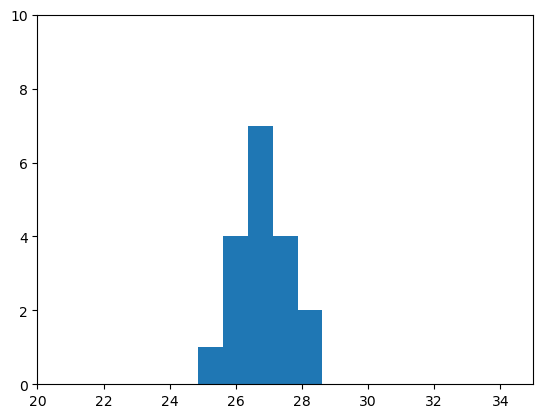

In [ ]:
plt.hist(doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good])-1],100)
plt.xlim(20,35)
plt.ylim(0,10)
plt.show()

In [ ]:
doltbl.Mag_WFC3_F336W[(msa_dol_ids[msa_dol_star_good])-1]
print('num of F336W non-detection', sum(doltbl.Mag_WFC3_F336W[(msa_dol_ids[msa_dol_star_good])-1] > 99),' / ',ngood_star)

num of F336W non-detection 9  /  23


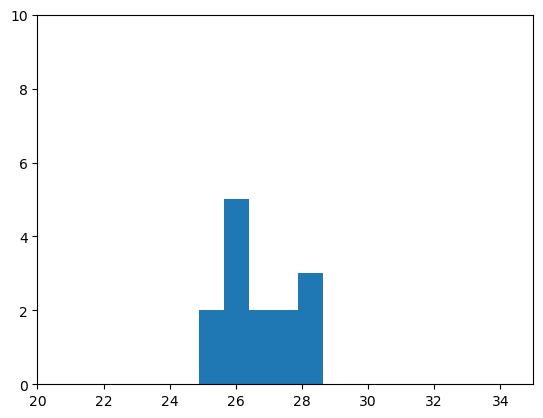

In [ ]:
plt.hist(doltbl.Mag_WFC3_F336W[(msa_dol_ids[msa_dol_star_good])-1],100)
plt.xlim(20,35)
plt.ylim(0,10)
plt.show()

In [ ]:
doltbl.Mag_WFC3_F438W[(msa_dol_ids[msa_dol_star_good])-1]
print('num of F438W non-detection', sum(doltbl.Mag_WFC3_F438W[(msa_dol_ids[msa_dol_star_good])-1] > 99),' / ',ngood_star)


num of F438W non-detection 2  /  23


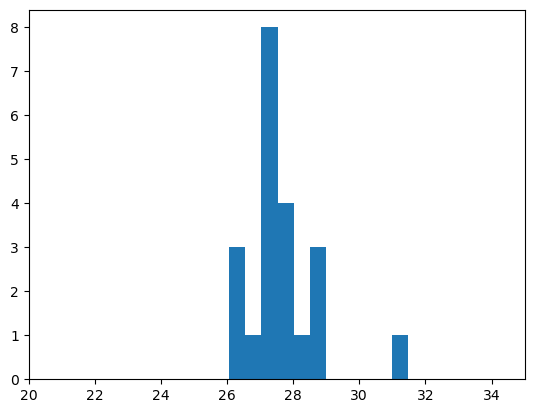

In [ ]:
plt.hist(doltbl.Mag_WFC3_F438W[(msa_dol_ids[msa_dol_star_good])-1],150)
plt.xlim(20,35)
plt.show()

In [ ]:
doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good])-1]
print('num of F814W non-detection', sum(doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good])-1] > 99),' / ',ngood_star)
(doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good])-1] < 99)

num of F814W non-detection 2  /  23


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True, False,  True,  True])

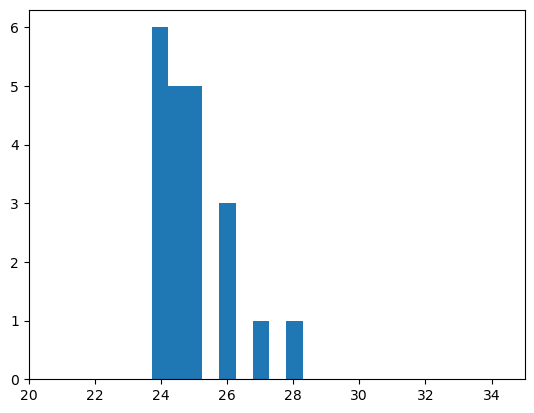

In [ ]:
plt.hist(doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good])-1],150)
plt.xlim(20,35)
plt.show()

In [ ]:
doltbl.Mag_WFC3_F555W[(msa_dol_ids[msa_dol_star_good])-1]
print('num of F555W non-detection', sum(doltbl.Mag_WFC3_F555W[(msa_dol_ids[msa_dol_star_good])-1] > 99),' / ',ngood_star)

num of F555W non-detection 1  /  23


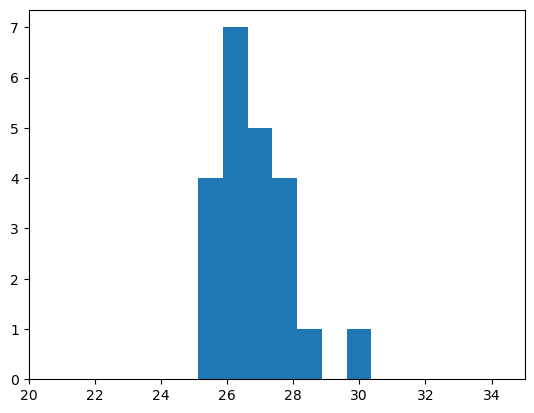

In [ ]:
plt.hist(doltbl.Mag_WFC3_F555W[(msa_dol_ids[msa_dol_star_good])-1],100)
plt.xlim(20,35)
plt.show()

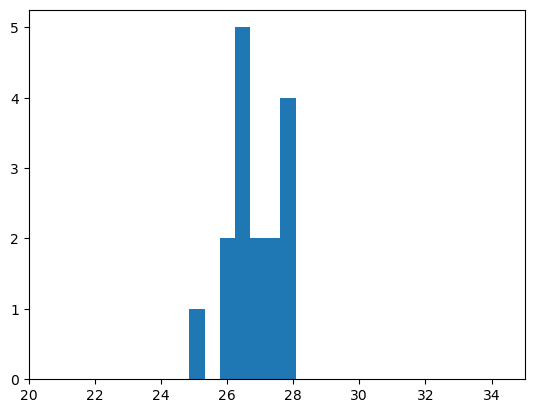

In [ ]:
plt.hist(doltbl.Mag_WFC3_F275W[(msa_dol_ids[msa_dol_star_good][msa_dol_detect_good])-1],7)
plt.xlim(20,35)
plt.show()


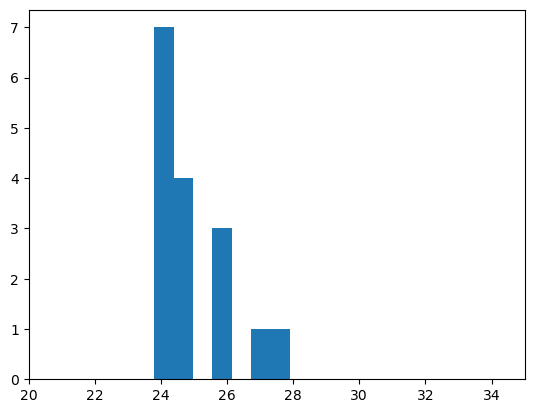

In [ ]:
plt.hist(doltbl.Mag_WFC3_F814W[(msa_dol_ids[msa_dol_star_good][msa_dol_detect_good])-1],7)
plt.xlim(20,35)
plt.show()

# Add Clusters to structures



In [ ]:
#read in cluster info
# ---------------------------------
# Read in Cluster Pipeline results
# ---------------------------------
clusterCat_all_file = gal+'_phangshst_cluster_allcandidates_v0_9.csv'
cluster_all = pd.read_csv(datadir+'catalogs/'+clusterCat_all_file,header=0)#,delim_whitespace= True
n_allclust = len(cluster_all.ID_PHANGS_ALLSOURCES_V0_9)
print('number of sources in cluster_allcandidates catalog',n_allclust)


number of sources in cluster_allcandidates catalog 4823


In [ ]:
#cluster_all

In [ ]:
ws0_cluster_ids = wsstructure.starchild(ws_idmap0,cluster_all.PHANGS_X,cluster_all.PHANGS_Y)
ws1_cluster_ids = wsstructure.starchild(ws_idmap1,cluster_all.PHANGS_X,cluster_all.PHANGS_Y)
ws2_cluster_ids = wsstructure.starchild(ws_idmap2,cluster_all.PHANGS_X,cluster_all.PHANGS_Y)

if nlevels==4:
    ws3_cluster_ids = wsstructure.starchild(ws_idmap3,cluster_all.PHANGS_X,cluster_all.PHANGS_Y)


In [ ]:
## Create dataframes for each scale level
#lvl0 = Level 0. For clusters that have no parent association at any level: orphan clusters.
#lvl1 = first scale level of the accociations
#empty ws0 dataframe
#lvl0['pc_scale'] = pc_scales[0] #scale level in parsecs

lvl0 = pd.DataFrame()

n_reg0 = np.max(ws_idmap0)
ws_id0 = range(1,n_reg0+1)
lvl0['id'] = ws_id0
lvl0['parent_ids'] = parent_ids
#level0['parent_ids'] = ws0_parent_ids
lvl0['nparent'] = nparent
lvl0['dolphot_ids']=ws0_dolphot_ids
lvl0['tracer_ids']= ws0_tracerstar_ids
lvl0['peak_xpos'] = reginfo_tbl0.peak_xpos
lvl0['peak_ypos'] = reginfo_tbl0.peak_ypos
lvl0['peak_ra'] = reginfo_tbl0.peak_ra
lvl0['peak_dec'] = reginfo_tbl0.peak_dec
lvl0['area_pc'] = reginfo_tbl0.area_pc
lvl0['rad_pc'] = reginfo_tbl0.rad_pc
lvl0['ntracer'] = reginfo_tbl0.ntracer_reg
#
lvl0['cluster_ids']= ws0_cluster_ids

lvl1 = pd.DataFrame()
n_reg1 = np.max(ws_idmap1)
ws_id1 = range(1,n_reg1+1)
lvl1['id'] = ws_id1
lvl1['parent_ids'] = ws1_parent_ids
lvl1['nparent'] = ws1_nparent
lvl1['child_ids'] = ws1_child_ids
lvl1['nchild'] = ws1_nchild
lvl1['child_noverlap'] = ws1_child_noverlap
lvl1['child_npix'] = ws1_child_npix
lvl1['dolphot_ids']=ws1_dolphot_ids
lvl1['tracer_ids']=ws1_tracerstar_ids
lvl1['peak_xpos'] = reginfo_tbl1.peak_xpos
lvl1['peak_ypos'] = reginfo_tbl1.peak_ypos
lvl1['peak_ra'] = reginfo_tbl1.peak_ra
lvl1['peak_dec'] = reginfo_tbl1.peak_dec
lvl1['area_pc'] = reginfo_tbl1.area_pc
lvl1['rad_pc'] = reginfo_tbl1.rad_pc
lvl1['ntracer'] = reginfo_tbl1.ntracer_reg
#
lvl1['cluster_ids']= ws1_cluster_ids


lvl2 = pd.DataFrame()
n_reg2 = np.max(ws_idmap2)
ws_id2 = range(1,n_reg2+1)
lvl2['id'] = ws_id2
#lvl2['parent_ids'] = ws2_parent_ids
#lvl2['nparent'] = ws2_nparent
lvl2['child_ids'] = ws2_child_ids
lvl2['nchild'] = ws2_nchild
lvl2['child_noverlap'] = ws2_child_noverlap
lvl2['child_npix'] = ws2_child_npix
lvl2['dolphot_ids']=ws2_dolphot_ids
lvl2['tracer_ids']=ws2_tracerstar_ids
lvl2['peak_xpos'] = reginfo_tbl2.peak_xpos
lvl2['peak_ypos'] = reginfo_tbl2.peak_ypos
lvl2['peak_ra'] = reginfo_tbl2.peak_ra
lvl2['peak_dec'] = reginfo_tbl2.peak_dec
lvl2['area_pc'] = reginfo_tbl2.area_pc
lvl2['rad_pc'] = reginfo_tbl2.rad_pc
lvl2['ntracer'] = reginfo_tbl2.ntracer_reg
#
lvl2['cluster_ids']= ws2_cluster_ids



0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2295   NaN
2296   NaN
2297   NaN
2298   NaN
2299   NaN
Name: pc_scale, Length: 2300, dtype: float64

In [ ]:
df_struct = {"lvl0":lvl0, "lvl1":lvl1, "lvl2":lvl2 } #create dictionary of data frames

In [ ]:
import pickle

struct_file = outdir+ gal+'_multi_level.pkl'
f = open(struct_file,"wb")
pickle.dump(df_struct,f)
f.close()
print(struct_file+' dictionary saved')

ngc1566_outfiles_vband_hpfilter2/ngc1566_multi_level.pkl dictionary saved


In [ ]:
df_struct['lvl1']

,id,parent_ids,nparent,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,ntracer,cluster_ids
0,1,[1],1,[],0,[],[],"[7761, 17072, 25004, 61488, 107109]","[4772, 11977, 18186]",3984.0,1011.0,64.996087,-54.966997,2034.292347,25.446716,3.0,[]
1,2,[2],1,[],0,[],[],"[16092, 25096, 88817, 103932, 134767, 134941, ...","[11177, 18254, 47189]",3786.0,1049.0,64.999883,-54.966579,1606.628615,22.614282,3.0,[2]
2,3,[2],1,[],0,[],[],"[14326, 27026, 31560, 202252, 281021, 321257, ...","[9792, 19744, 23206]",3789.0,1062.0,64.999825,-54.966436,1606.628615,22.614282,3.0,[]
3,4,[4],1,[],0,[],[],"[25306, 35495, 37288, 41805, 43150, 52852, 553...","[18405, 26152, 27472, 30635, 31520, 37457, 387...",3817.0,1074.0,64.999289,-54.966304,4415.339071,37.489279,8.0,[]
4,5,[5],1,[],0,[],[],"[15920, 29760, 197779, 201918]","[11045, 21835]",3954.0,1089.0,64.996662,-54.966139,1433.251426,21.359263,2.0,[7]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3243,3244,[2006],1,[2297],1,[27],[27],"[4941, 12676, 68064, 168401]","[2853, 8527, 43695]",3395.0,6330.0,65.007370,-54.908459,1329.225113,20.569528,3.0,[4817]
3244,3245,[2009],1,[2298],1,[52],[52],"[11029, 14067, 23003, 35133, 49677, 51211, 576...","[7244, 9576, 16607, 25884, 36543, 39811, 45642...",3500.0,6331.0,65.005360,-54.908448,3536.894649,33.553368,8.0,[4818]
3245,3246,[],0,[],0,[],[],"[10440, 12079, 26674, 99423, 105076, 178285, 1...","[6777, 8054, 19448]",3420.0,6348.0,65.006892,-54.908261,1733.771887,23.492057,3.0,[]
3246,3247,[2009],1,[2299],1,[47],[47],"[17434, 28080, 33946, 40424, 40595, 69045, 955...","[12252, 20549, 25029, 29669, 29783, 43968]",3508.0,6355.0,65.005207,-54.908184,2854.944373,30.145597,6.0,"[4819, 4820]"


In [ ]:
multi_parent0 = np.where(df_struct['lvl0'].nparent > 1)
print(len(multi_parent0[0]))
multi_parent = np.where(df_struct['lvl1'].nparent > 1)
print(len(multi_parent[0]))


12
101


In [ ]:
lvl2_id2005_child = df_struct['lvl2'].child_ids[2005]
print(lvl2_id2005_child)

array([3237, 3239, 3241, 3244], dtype=int32)

In [ ]:
df_struct['lvl1'].dolphot_ids[lvl2_id2005_child-1]
df_struct['lvl1'].dolphot_ids[df_struct['lvl2'].child_ids[2005]-1]

3236    [24840, 39598, 48907, 60446, 64634, 67000, 683...
3238    [33720, 85191, 87247, 111961, 168487, 170232, ...
3240    [6958, 11313, 32009, 34094, 35280, 35998, 3801...
3243                         [4941, 12676, 68064, 168401]
Name: dolphot_ids, dtype: object

In [ ]:
#Must read in PHOT TABLE
#plot example

    #--------------------------------
    #Color Color Plot
    #  Add PHANGS Class 1 clusters
    plt.scatter( phot_tbl.v_dolmag - phot_tbl.i_dolmag, phot_tbl.u_dolmag - phot_tbl.b_dolmag,alpha=0.8,s=4)

    plt.plot(bc03_V_vega-bc03_I_vega,bc03_U_vega-bc03_B_vega,color='red',label='BC03 solar')
    plt.title(gal+' ws level: '+str(pc_scales[i].astype(np.int)))

    plt.scatter(cluster_all.PHANGS_F555W_VEGA_AP4[PHANGS_class1]- cluster_all.PHANGS_F814W_VEGA_AP4[PHANGS_class1],cluster_all.PHANGS_F336W_VEGA_AP4[PHANGS_class1]- cluster_all.PHANGS_F438W_VEGA_AP4[PHANGS_class1],s=20,marker='o',color='red',edgecolor='black',label='PHANGS class 1')


    plt.ylabel('U (F336W)- B (F438W)')
    plt.xlabel('V (F555W)- I (F814W)')

    plt.ylim(-2.0, 1.0)
    plt.xlim(-1.5, 2.3)
    plt.gca().invert_yaxis()

    plt.legend(loc='lower left', frameon=True)
    py.savefig(outdir4+gal+'_'+tracer_band+'_hpfilt'+smooth_step+'_dolphot_color_vi_ub_ws'+str(pc_scales[i].astype(np.int))+'pc_PhangsClass1'+'.pdf', bbox_inches='tight', pad_inches=0.15)
    plt.close()

In [ ]:
print(df_struct.keys())


dict_keys(['lvl0', 'lvl1', 'lvl2'])


In [ ]:
#can't make a df of dfs
df_struct = pd.DataFrame()
df_struct['lvl0']=lvl0
df_struct['lvl1']=lv11
df_struct['lvl2']=lv12
##

In [ ]:
 lvl2

,id,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,ntracer,cluster_ids
0,1,[1],1,[176],[176],"[4129, 7761, 9995, 10070, 10551, 17072, 25004,...","[4772, 6863, 11977, 18186]",3985.0,1014.0,64.996068,-54.966964,7651.713259,49.351960,4.0,[]
1,2,"[2, 3]",2,"[139, 139]","[139, 139]","[14326, 14680, 16092, 18271, 25096, 27026, 315...","[9792, 10072, 11177, 12923, 18254, 19744, 2320...",3787.0,1057.0,64.999864,-54.966491,13419.394402,65.356912,10.0,"[2, 3, 4]"
2,3,[],0,[],[],"[17626, 46566, 103751, 125177, 234533, 306048]","[12410, 33730]",3683.0,1068.0,65.001857,-54.966370,3883.649026,35.159691,2.0,[5]
3,4,[4],1,[382],[382],"[25306, 35495, 37288, 41805, 43150, 52852, 553...","[18405, 26152, 27472, 30635, 31520, 37457, 387...",3815.0,1078.0,64.999327,-54.966260,10992.113761,59.151488,8.0,[]
4,5,[5],1,[124],[124],"[15920, 29760, 93302, 197779, 201822, 201918]","[11045, 21835]",3954.0,1090.0,64.996662,-54.966128,3652.479441,34.097219,2.0,[7]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005,2006,"[3237, 3239, 3241, 3244]",4,"[244, 114, 345, 112]","[244, 145, 345, 115]","[4941, 6958, 11313, 12676, 19943, 24840, 24893...","[2853, 4212, 7474, 8527, 14198, 18058, 18095, ...",3408.0,6308.0,65.007122,-54.908701,31774.259441,100.568688,40.0,"[4810, 4811, 4812, 4813, 4814, 4815, 4817]"
2006,2007,[3242],1,[147],[147],"[30167, 45467, 48687, 53260, 55382, 59923, 688...","[22148, 33029, 35042, 37683, 45595]",3592.0,6324.0,65.003599,-54.908525,8657.300953,52.494804,5.0,[4816]
2007,2008,[3243],1,[157],[157],"[2132, 3360, 3727, 3955, 13945, 14342, 15760, ...","[9477, 10930, 12677, 15510, 33220, 35228]",3317.0,6325.0,65.008864,-54.908514,10541.333070,57.925906,6.0,[]
2008,2009,"[3245, 3247]",2,"[306, 247]","[306, 247]","[11029, 14067, 17434, 23003, 28080, 33946, 351...","[7244, 9576, 12252, 16607, 20549, 25029, 25884...",3501.0,6331.0,65.005341,-54.908448,24896.964291,89.022188,19.0,"[4818, 4819, 4820]"


In [ ]:
def orphan(ws_idmap,x,y,ws_idmap1=None,ws_idmap2=None,ws_idmap3=None,ws_idmap4=None):
    #find clusters that are not contained in any parent region
    #returns index from the x,y arrays that are orphans
    #list nearest region neighbors? # at all levels?
    #

    x = np.round(x).astype(int) #makes sure that the input x and y are integer arrays
    y = np.round(y).astype(int)

    id_tst0=ws_idmap0[x,y]
    orphan = np.where(id_tst0==0)

    if ws_idmap1 is not None:
        id_tst1=ws_idmap1[x,y]
        orphan = np.where((id_tst0==0) & (id_tst1 ==0))

    if ws_idmap2 is not None:
        id_tst2=ws_idmap2[x,y.astype(int)]
        orphan = np.where((id_tst0==0) & (id_tst1 ==0) & (id_tst2 ==0))

    if ws_idmap3 is not None:
        id_tst3=ws_idmap3[x,y]
        orphan = np.where((id_tst0==0) & (id_tst1 ==0) & (id_tst2 ==0) & (id_tst3 ==0))

    if ws_idmap4 is not None:
        id_tst4=ws_idmap4[x,y]
        orphan = np.where((id_tst0==0) & (id_tst1 ==0) & (id_tst2 ==0) & (id_tst3 ==0) & (id_tst4 ==0))

    orphan_ids = orphan[0]
    return orphan_ids


In [ ]:
compact = np.where((cluster_all.PHANGS_CLUSTER_CLASS > 0) & (cluster_all.PHANGS_CLUSTER_CLASS < 3))
print(len(compact[0]))
cluster_all.PHANGS_CLUSTER_CLASS[compact[0]]

303


10      1.0
12      2.0
13      1.0
14      2.0
19      2.0
       ... 
2629    2.0
2631    1.0
2632    1.0
2633    2.0
2635    2.0
Name: PHANGS_CLUSTER_CLASS, Length: 303, dtype: float64

In [ ]:
tst = orphan(ws_idmap0,cluster_all.PHANGS_X,cluster_all.PHANGS_Y)
print(len(tst))

tst = orphan(ws_idmap0,cluster_all.PHANGS_X,cluster_all.PHANGS_Y,ws_idmap1)
print(len(tst))

tst = orphan(ws_idmap0,cluster_all.PHANGS_X[compact[0]],cluster_all.PHANGS_Y[compact[0]],ws_idmap1,ws_idmap2)
print(len(tst))


4769
4505
259


In [ ]:
tst

array([   0,    1,    2, ..., 4820, 4821, 4822])

In [ ]:
cluster_all.PHANGS_RA[tst]

0       64.998014
1       64.997014
2       64.999886
3       65.000410
4       65.000339
          ...    
4818    65.005349
4819    65.005201
4820    65.005199
4821    65.006106
4822    65.007415
Name: PHANGS_RA, Length: 4027, dtype: float64

In [ ]:
cluster_all.ID_PHANGS_CLUSTERS_V0_9[tst]

0          1
1          2
2          3
3          4
4          5
        ... 
4818    4819
4819    4820
4820    4821
4821    4822
4822    4823
Name: ID_PHANGS_CLUSTERS_V0_9, Length: 4027, dtype: int64

In [ ]:
compact = np.where((cluster_all.PHANGS_CLUSTER_CLASS > 0) & (cluster_all.PHANGS_CLUSTER_CLASS < 4))
compact = compact[0]

tst = orphan(ws_idmap0,cluster_all.PHANGS_X[compact],cluster_all.PHANGS_Y[compact],ws_idmap1,ws_idmap2)
print(len(compact))
print(len(tst))

lvl = pd.DataFrame()
lvl['phangs_id'] = cluster_all.ID_PHANGS_CLUSTERS_V0_9[compact[tst]]
lvl['cluster_ra'] =cluster_all.PHANGS_RA[compact[tst]]
lvl['cluster_dec'] =cluster_all.PHANGS_DEC[compact[tst]]
lvl['cluster_x'] =cluster_all.PHANGS_X[compact[tst]]
lvl['cluster_y'] =cluster_all.PHANGS_Y[compact[tst]]
lvl['cluster_class'] =cluster_all.PHANGS_CLUSTER_CLASS[compact[tst]]

374
321


In [ ]:
a = np.where(lvl.cluster_class <3)
print(len(a[0]))
print(a[0])

177
[  2   3   4   7   9  11  12  13  14  16  20  21  23  25  26  27  29  30
  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  49
  50  52  54  55  56  58  59  60  61  62  63  64  65  66  67  68  69  70
  72  73  74  75  76  77  79  80  81  82  83  84  86  87  89  90  91  92
  94  95  96  97  98  99 100 101 102 103 104 107 110 112 113 115 116 117
 118 121 122 123 124 125 126 127 128 129 131 132 133 134 136 137 139 141
 142 143 144 145 148 149 150 151 152 153 154 155 156 159 160 161 162 163
 166 168 171 172 175 176 177 180 185 187 188 189 192 193 196 197 199 202
 203 204 205 208 209 210 211 212 215 218 219 222 224 225 226 228 230 231
 232 233 234 235 237 238 239 240 243 244 247 248 249 250 251]


In [ ]:
lvl

,phangs_id,cluster_ra,cluster_dec,cluster_x,cluster_y,cluster_class
10,11,64.994046,-54.965503,4089.96,1146.21,1.0
12,13,65.000012,-54.964852,3778.75,1205.44,2.0
13,14,64.996656,-54.964705,3953.84,1218.82,1.0
14,15,65.004487,-54.964654,3545.34,1223.38,2.0
16,17,65.005126,-54.964549,3512.02,1232.92,3.0
...,...,...,...,...,...,...
2625,2626,64.976202,-54.936473,5021.70,3783.76,1.0
2629,2630,65.021196,-54.936458,2673.05,3785.26,2.0
2631,2632,64.977785,-54.936421,4939.04,3788.58,1.0
2632,2633,64.977007,-54.936415,4979.69,3789.12,1.0


In [ ]:
cluster_all.columns

Index(['ID_PHANGS_CLUSTERS_V0_9', 'ID_PHANGS_ALLSOURCES_V0_9', 'PHANGS_X',
       'PHANGS_Y', 'PHANGS_RA', 'PHANGS_DEC', 'PHANGS_CLUSTER_CLASS',
       'PHANGS_CLUSTER_MLCLASS_RESNET_MODE',
       'PHANGS_CLUSTER_MLCLASS_RESNET_STDEV',
       'PHANGS_CLUSTER_MLCLASS_VGG_MODE', 'PHANGS_CLUSTER_MLCLASS_VGG_STDEV',
       'PHANGS_F275W_VEGA_AP4', 'PHANGS_F275W_VEGA_AP4_ERR',
       'PHANGS_F336W_VEGA_AP4', 'PHANGS_F336W_VEGA_AP4_ERR',
       'PHANGS_F438W_VEGA_AP4', 'PHANGS_F438W_VEGA_AP4_ERR',
       'PHANGS_F555W_VEGA_AP4', 'PHANGS_F555W_VEGA_AP4_ERR',
       'PHANGS_F814W_VEGA_AP4', 'PHANGS_F814W_VEGA_AP4_ERR',
       'PHANGS_F275W_mJY_AP4', 'PHANGS_F275W_mJY_AP4_ERR',
       'PHANGS_F336W_mJY_AP4', 'PHANGS_F336W_mJY_AP4_ERR',
       'PHANGS_F438W_mJY_AP4', 'PHANGS_F438W_mJY_AP4_ERR',
       'PHANGS_F555W_mJY_AP4', 'PHANGS_F555W_mJY_AP4_ERR',
       'PHANGS_F814W_mJY_AP4', 'PHANGS_F814W_mJY_AP4_ERR', 'PHANGS_CI',
       'PHANGS_MCI_IN', 'PHANGS_MCI_IN_ERR', 'PHANGS_MCI_OUT',
       'PH

In [ ]:
#READ IN Saved Dictionary

In [ ]:
import pickle
pkl_file = outdir+ gal+'_multi_level.pkl'
print(pkl_file)

/Users/kilarson/Library/CloudStorage/Box-Box/My Documents - Kirsten Larson/Kirsten_PHANGS/Hierarchical_analysis/ngc4826_outfiles_nuvband/ngc4826_multi_level.pkl


In [ ]:
# read python dict back from the file
pkl_file = outdir+ gal+'_multi_level.pkl'
multi_level_pkl = open(pkl_file, 'rb')
mlevel_dict = pickle.load(multi_level_pkl)
multi_level_pkl.close()

In [ ]:
mlevel_dict

{'lvl0':       id parent_ids  nparent  \
 0      1        [1]        1   
 1      2        [2]        1   
 2      3        [4]        1   
 3      4        [5]        1   
 4      5        [6]        1   
 ..   ...        ...      ...   
 572  573      [449]        1   
 573  574      [450]        1   
 574  575      [452]        1   
 575  576      [453]        1   
 576  577      [454]        1   
 
                                            dolphot_ids  \
 0    [41361, 45077, 59644, 71262, 152800, 155077, 2...   
 1                         [1238, 8687, 114044, 116110]   
 2                 [7874, 26220, 65160, 173220, 226957]   
 3    [31540, 55967, 59735, 115199, 189099, 197439, ...   
 4    [5712, 9873, 33915, 71871, 89718, 162628, 1815...   
 ..                                                 ...   
 572  [6546, 11105, 59217, 61889, 75117, 77950, 8558...   
 573  [4525, 10191, 18273, 18649, 19648, 21427, 6178...   
 574  [6659, 7437, 23614, 51846, 61012, 97152, 13427...   
 575

In [ ]:
mlevel_dict['lvl3']

,id,child_ids,nchild,child_noverlap,child_npix,dolphot_ids,tracer_ids,peak_xpos,peak_ypos,peak_ra,peak_dec,area_pc,rad_pc,V_dolflux_mjy,NUV_dolflux_mjy
0,1,[1],1,[3397],[3397],"[8418, 12081, 22112, 29843, 29937, 32504, 3250...","[6045, 6244, 8079, 9340]",4142.0,2403.0,194.178139,21.668148,7841.727918,49.960980,0.028541,0.005619
1,2,[],0,[],[],"[408, 569, 702, 1418, 2272, 2437, 2590, 2679, ...","[842, 6724, 7902, 8860, 9088, 9578]",2691.0,2445.0,194.195322,21.668610,10297.783793,57.252829,0.035806,0.036103
2,3,[],0,[],[],"[16051, 18700, 25345, 28912, 30219, 32907, 330...","[8996, 9219, 9470, 9533]",2879.0,2452.0,194.193095,21.668687,5957.531970,43.547001,0.024099,0.004816
3,4,"[5, 7, 8]",3,"[11008, 3386, 458]","[11008, 3386, 1560]","[2771, 3332, 3480, 3731, 4188, 5209, 5409, 564...","[1466, 1800, 1859, 2367, 2550, 2699, 2748, 290...",3403.0,2796.0,194.186890,21.672473,23321.409324,86.159359,0.152505,0.047171
4,5,"[4, 6, 11, 12, 13, 19, 27]",7,"[4, 15442, 4207, 8691, 1928, 2006, 2794]","[1109, 15442, 4344, 8721, 2418, 2372, 4683]","[613, 1114, 1161, 1180, 1203, 1325, 1441, 1589...","[226, 413, 441, 454, 546, 716, 796, 843, 873, ...",3111.0,2799.0,194.190348,21.672506,49725.265636,125.809553,0.411517,0.188902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,[248],1,[2745],[3157],"[8208, 10188, 14233, 15446, 23649, 23772, 2483...","[3946, 8437, 8445, 8973]",4929.0,4748.0,194.168817,21.693956,2292.462320,27.013208,0.011213,0.002444
87,88,[249],1,[1854],[1854],"[4698, 12840, 14316, 15370, 15452, 16996, 1734...","[6872, 7798, 8018, 8091, 9226, 9400]",5201.0,5026.0,194.165595,21.697015,13531.626571,65.629647,0.048657,0.008181
88,89,[250],1,[1833],[1833],"[6458, 6659, 7437, 14243, 18196, 23614, 23706,...","[2202, 2418]",4034.0,5073.0,194.179417,21.697533,4391.195430,37.386641,0.017816,0.004061
89,90,[251],1,[1773],[1773],"[5728, 14139, 15467, 16186, 16687, 19449, 2091...","[4959, 6433, 9515]",4759.0,5230.0,194.170830,21.699260,5999.865390,43.701447,0.020880,0.004519


In [ ]:
tstdir = '/Users/klarson/Downloads/'
file = 'ngc1365_phangs-hst_v1p1_human_class3.fits'


In [15]:
import os

path_to_list = '/content/drive/Shared drives/PHANGS/Archive/Products/cluster_catalogs/IR4/multiscale_stellar_associations/ngc4826/nuvselect/ws16pc/'

if os.path.exists(path_to_list):
    files_in_dir = os.listdir(path_to_list)
    print(f"Files in {path_to_list}:")
    for f in files_in_dir:
        print(f)
else:
    print(f"Directory not found: {path_to_list}")

Files in /content/drive/Shared drives/PHANGS/Archive/Products/cluster_catalogs/IR4/multiscale_stellar_associations/ngc4826/nuvselect/ws16pc/:
PHANGS_IR4_hst_wfc3_ngc4826_v1p3_multi_assoc-nuvselect-ws16pc-region.reg
PHANGS_IR4_hst_wfc3_ngc4826_v1p3_multi_assoc-nuvselect-ws16pc-main.fits
PHANGS_IR4_hst_wfc3_ngc4826_v1p3_multi_assoc-nuvselect-ws16pc-peaks.reg
PHANGS_IR4_hst_wfc3_ngc4826_v1p3_multi_assoc-nuvselect-ws16pc-idmask.fits.gz


In [17]:
print(imgfile)

/content/drive/Shared drives/PHANGS/Archive/Products/cluster_catalogs/IR4/multiscale_stellar_associations/ngc4826/nuvselect/ws16pc/PHANGS_IR4_hst_wfc3_ngc4826_v1p3_multi_assoc-nuvselect-ws16pc-idmask.fits
